# 02 - Target Selection & Problem Definition

## Selección de predicciones candidatas y definición del problema de Machine Learning

En este notebook se define formalmente qué problemas de Machine Learning serán trabajados en el proyecto.

Después de preparar el dataset en el notebook `00_data_cleaning_feature_engineering.ipynb` y analizar el comportamiento operacional en `01_business_context_and_eda.ipynb`, corresponde evaluar distintas variables objetivo posibles.

La finalidad de este notebook es comparar varias predicciones candidatas y justificar cuáles serán utilizadas como enfoque principal del proyecto.

Las predicciones evaluadas son:

- `tiene_incidencia`
- `entrega_tardia`
- `entrega_tardia_v3`
- `incidencia_multiclase`
- `riesgo_operacional_alto`
- `riesgo_operacional`

Al final se seleccionan dos enfoques finales:

1. **Clasificación:** `riesgo_operacional_alto`
2. **Regresión:** `riesgo_operacional`


# Objetivo del notebook

En este notebook busco:

- definir las variables objetivo candidatas;
- revisar la distribución de cada target;
- identificar problemas como desbalance extremo o targets no modelables;
- realizar una comparación inicial de modelos;
- interpretar métricas de clasificación y regresión;
- justificar por qué algunas predicciones se descartan;
- seleccionar la predicción principal de clasificación y regresión.

Este notebook es importante porque no basta con entrenar modelos.  
Primero se debe definir correctamente qué problema se quiere resolver.


# 1. Contexto metodológico

En Machine Learning, la elección del target es una de las decisiones más importantes del proyecto.

Un target puede parecer interesante desde el negocio, pero no necesariamente ser adecuado para modelado si:

- tiene una sola clase;
- está extremadamente desbalanceado;
- no tiene relación clara con las variables disponibles;
- genera métricas engañosas;
- depende de información que solo se conoce después del evento.

Por eso, antes de avanzar al modelado final, se comparan varias formulaciones posibles del problema.


# 2. Configuración inicial

Importo las librerías necesarias para análisis, visualización y pruebas iniciales de modelos.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


# 3. Carga del dataset V3

Cargo el dataset transformado en la etapa de limpieza y feature engineering.

Este dataset será la base para comparar las predicciones candidatas.


In [2]:
df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("Dimensiones del dataset:", df.shape)

df.head()


Dimensiones del dataset: (998, 56)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia,peso_kg_original,distancia_km_original,velocidad_promedio_km_h_original,uso_capacidad_kg_original,uso_capacidad_m3_original,uso_capacidad_kg_recalculado,uso_capacidad_m3_recalculado,antiguedad_vehiculo,densidad_carga,riesgo_operacional,riesgo_velocidad,vehiculo_exigido,sobrecarga_kg,ruta_larga,velocidad_alta,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1,12675.8,919.3,55.047904,1.26758,1.389268,1.26758,1.389268,4.0,445.061620,1165.286294,50605.538323,1,1,0,0,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1,13.6,679.6,36.934783,0.01360,1.128054,0.01360,1.128054,16.0,0.545506,9.242560,25100.878261,0,0,0,0,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1,2536.0,468.4,90.076923,0.12680,1.299486,0.12680,1.299486,3.0,50.167158,59.393120,42192.030769,0,0,0,0,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1,466.0,1642.4,86.899471,0.46600,0.548617,0.46600,0.548617,11.0,33.571068,765.358400,142723.691005,0,0,1,0,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1,4928.9,1556.6,86.960894,0.98578,0.008961,0.98578,0.008961,3.0,11176.643991,1534.465148,135363.327374,1,0,1,0,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891


## Análisis inicial

El dataset V3 contiene 998 registros y 56 columnas.

Esta versión ya incluye:

- variables originales tratadas;
- ratios recalculados;
- variables derivadas operacionales;
- transformaciones logarítmicas;
- variables relacionadas con riesgo y exigencia logística.

Por eso es una base adecuada para evaluar diferentes problemas predictivos.


# 4. Creación y verificación de targets candidatos

En esta sección se construyen o verifican las variables objetivo que serán comparadas.

Se consideran tanto problemas de clasificación como de regresión.


In [3]:
# Target 1: incidencia binaria.
df["tiene_incidencia"] = df["tiene_incidencia"].astype(int)

# Target 2: entrega tardía original.
if "entrega_tardia" in df.columns:
    df["entrega_tardia"] = df["entrega_tardia"].astype(int)
else:
    df["entrega_tardia"] = np.where(df["dias_entrega"] > 7, 1, 0)

# Target 3: entrega tardía V3.
percentil_entrega = df["dias_entrega"].quantile(0.75)

df["entrega_tardia_v3"] = np.where(
    df["dias_entrega"] >= percentil_entrega,
    1,
    0
)

# Target 4: incidencias multiclase.
df["incidencia_multiclase"] = np.select(
    [
        df["cantidad_incidencias"] == 0,
        df["cantidad_incidencias"] == 1,
        df["cantidad_incidencias"] >= 2
    ],
    [
        0,
        1,
        2
    ],
    default=0
)

# Target 5: riesgo operacional alto.
percentil_riesgo = df["riesgo_operacional"].quantile(0.75)

df["riesgo_operacional_alto"] = np.where(
    df["riesgo_operacional"] >= percentil_riesgo,
    1,
    0
)

print("Percentil 75 dias_entrega:", percentil_entrega)
print("Percentil 75 riesgo_operacional:", percentil_riesgo)


Percentil 75 dias_entrega: 7.0
Percentil 75 riesgo_operacional: 2279.9541040000004


## Interpretación de los targets creados

Cada target representa una forma distinta de plantear el problema:

| Target | Tipo | Pregunta que responde |
|---|---|---|
| `tiene_incidencia` | Clasificación binaria | ¿El envío tendrá alguna incidencia? |
| `entrega_tardia` | Clasificación binaria | ¿El envío fue marcado como tardío? |
| `entrega_tardia_v3` | Clasificación binaria | ¿El envío pertenece al grupo de entregas más tardías? |
| `incidencia_multiclase` | Clasificación multiclase | ¿El envío no tiene, tiene una o tiene múltiples incidencias? |
| `riesgo_operacional_alto` | Clasificación binaria | ¿El envío tiene alto riesgo operacional? |
| `riesgo_operacional` | Regresión | ¿Cuál es el nivel estimado de riesgo operacional? |

La comparación permitirá decidir cuál formulación es más sólida y útil.


# 5. Distribución de targets candidatos

Antes de entrenar modelos, reviso la distribución de cada variable objetivo.

Esto permite detectar problemas como desbalance o targets con una sola clase.



Distribución del target: tiene_incidencia



tiene_incidencia
0    834
1    164
Name: count, dtype: int64


tiene_incidencia
0    83.567134
1    16.432866
Name: proportion, dtype: float64

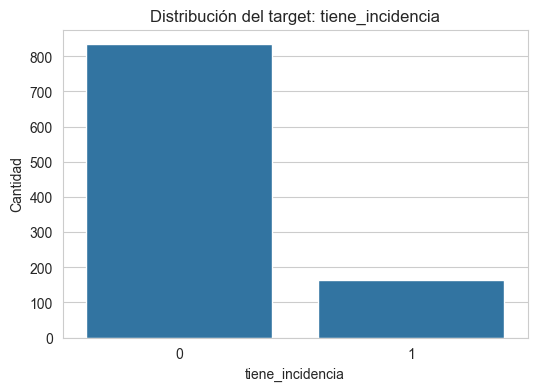


Distribución del target: entrega_tardia



entrega_tardia
1    998
Name: count, dtype: int64


entrega_tardia
1    100.0
Name: proportion, dtype: float64

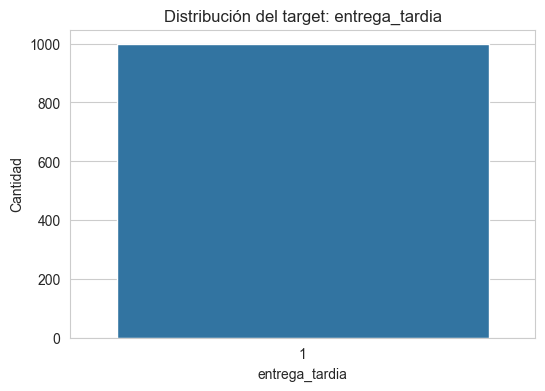


Distribución del target: entrega_tardia_v3



entrega_tardia_v3
1    925
0     73
Name: count, dtype: int64


entrega_tardia_v3
1    92.685371
0     7.314629
Name: proportion, dtype: float64

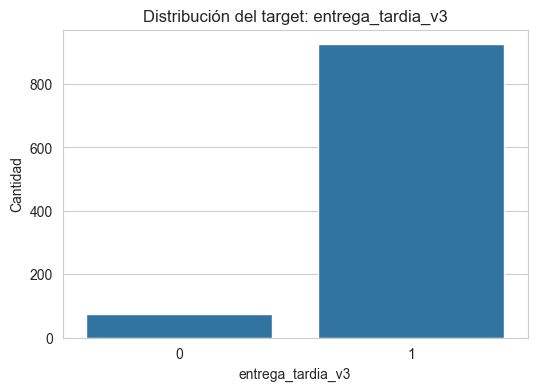


Distribución del target: incidencia_multiclase



incidencia_multiclase
0    834
1    153
2     11
Name: count, dtype: int64


incidencia_multiclase
0    83.567134
1    15.330661
2     1.102204
Name: proportion, dtype: float64

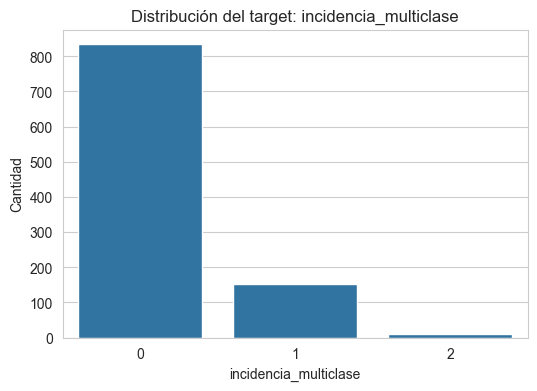


Distribución del target: riesgo_operacional_alto



riesgo_operacional_alto
0    755
1    243
Name: count, dtype: int64


riesgo_operacional_alto
0    75.651303
1    24.348697
Name: proportion, dtype: float64

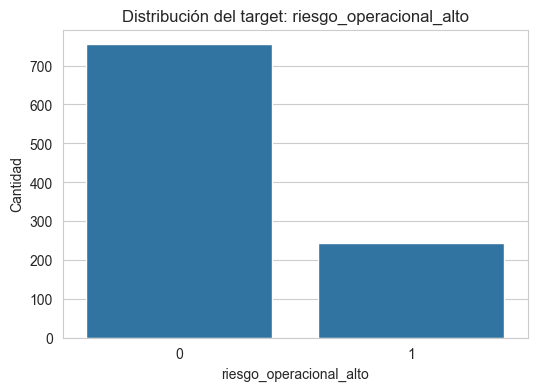

In [4]:
targets_clasificacion = [
    "tiene_incidencia",
    "entrega_tardia",
    "entrega_tardia_v3",
    "incidencia_multiclase",
    "riesgo_operacional_alto"
]

for target in targets_clasificacion:
    print("\n" + "="*60)
    print(f"Distribución del target: {target}")
    print("="*60)

    display(df[target].value_counts(dropna=False))
    display(df[target].value_counts(normalize=True, dropna=False) * 100)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target)
    plt.title(f"Distribución del target: {target}")
    plt.xlabel(target)
    plt.ylabel("Cantidad")
    plt.show()


## Análisis de distribuciones

Las distribuciones muestran diferencias importantes entre targets:

- `tiene_incidencia` está desbalanceado: cerca del 16% corresponde a incidencias.
- `entrega_tardia` no es modelable, ya que todos los registros pertenecen a la misma clase.
- `entrega_tardia_v3` parece tener buen F1 en modelos iniciales, pero está muy desbalanceada: más del 92% pertenece a una sola clase.
- `incidencia_multiclase` también está desbalanceada, especialmente porque la clase de múltiples incidencias representa cerca del 1%.
- `riesgo_operacional_alto` tiene una distribución más utilizable, con aproximadamente 24% de alto riesgo.

Esto indica que no todos los targets son igual de adecuados para Machine Learning.


# 6. Variables predictoras candidatas

Se define una lista de variables predictoras que serán utilizadas para hacer una comparación inicial entre targets.

No se incluye `riesgo_operacional` como predictor directo, porque será utilizado como target de regresión y como base para `riesgo_operacional_alto`.


In [5]:
variables_base = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("Cantidad de variables usadas:", len(variables_modelo))
variables_modelo


Cantidad de variables usadas: 32



[
    'distancia_km',
    'tiempo_estimado_hrs',
    'peso_kg',
    'volumen_m3',
    'capacidad_kg',
    'capacidad_m3',
    'velocidad_promedio_km_h',
    'km_recorridos',
    'tipo_via',
    'tipo_carga',
    'estado_vehiculo',
    'tipo',
    'uso_capacidad_kg',
    'uso_capacidad_m3',
    'uso_capacidad_kg_recalculado',
    'uso_capacidad_m3_recalculado',
    'antiguedad_vehiculo',
    'densidad_carga',
    'riesgo_velocidad',
    'vehiculo_exigido',
    'sobrecarga_kg',
    'ruta_larga',
    'velocidad_alta',
    'vehiculo_riesgoso_estado',
    'via_compleja',
    'peso_kg_log',
    'distancia_km_log',
    'volumen_m3_log',
    'velocidad_promedio_km_h_log',
    'densidad_carga_log',
    'riesgo_velocidad_log',
    'km_recorridos_log'
]

## Nota sobre fuga de información

Es importante evitar variables que entreguen información directa del resultado.

Por ejemplo, para predecir incidencias no se deberían usar variables como:

- `cantidad_incidencias`;
- `costo_total_incidencias`;
- `tipo_incidencia_principal`.

Estas columnas se conocen después de ocurrida la incidencia, por lo tanto podrían generar fuga de información.

La selección de variables se mantiene enfocada en información operacional disponible antes o durante la planificación del envío.


# 7. Preprocesamiento común para comparación inicial

Se utiliza un mismo preprocesamiento para todos los modelos:

- variables numéricas: imputación con mediana y escalamiento;
- variables categóricas: imputación con moda y One Hot Encoding.

Esto permite comparar modelos de forma más justa.


In [6]:
def crear_preprocesador(X):
    variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador


# 8. Función de comparación inicial de clasificación

Esta función permite entrenar varios modelos de clasificación sobre cada target candidato.

Los modelos utilizados son:

- Logistic Regression;
- Decision Tree;
- Random Forest;
- KNN;
- SVM;
- Gaussian Naive Bayes.

La finalidad no es optimizar todavía, sino obtener una primera evidencia para decidir qué target es más adecuado.


In [7]:
def evaluar_clasificacion(target):

    datos = df[variables_modelo + [target]].dropna(subset=[target]).copy()

    X = datos[variables_modelo]
    y = datos[target]

    if y.nunique() < 2:
        print(f"El target {target} no se puede modelar porque tiene una sola clase.")
        return pd.DataFrame([{
            "target": target,
            "modelo": "No modelable",
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1_score": np.nan,
            "observacion": "Target con una sola clase"
        }]), None

    stratify_y = y if y.value_counts().min() >= 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=stratify_y
    )

    preprocesador = crear_preprocesador(X)

    modelos = {
        "Logistic Regression": LogisticRegression(
            random_state=42,
            max_iter=3000,
            class_weight="balanced"
        ),
        "Decision Tree": DecisionTreeClassifier(
            random_state=42,
            max_depth=6,
            class_weight="balanced"
        ),
        "Random Forest": RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            max_depth=8,
            class_weight="balanced"
        ),
        "KNN": KNeighborsClassifier(),
        "SVM": SVC(
            random_state=42,
            class_weight="balanced"
        ),
        "Gaussian NB": GaussianNB()
    }

    resultados = []

    for nombre, modelo in modelos.items():

        pipeline = Pipeline([
            ("preprocesamiento", preprocesador),
            ("modelo", modelo)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        promedio = "weighted" if y.nunique() > 2 else "binary"

        resultados.append({
            "target": target,
            "modelo": nombre,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average=promedio, zero_division=0),
            "recall": recall_score(y_test, y_pred, average=promedio, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, average=promedio, zero_division=0),
            "observacion": "Modelado correctamente"
        })

    tabla = pd.DataFrame(resultados).sort_values(
        by="f1_score",
        ascending=False
    )

    mejor_modelo_nombre = tabla.iloc[0]["modelo"]

    pipeline_final = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", modelos[mejor_modelo_nombre])
    ])

    pipeline_final.fit(X_train, y_train)
    y_pred_final = pipeline_final.predict(X_test)

    mejor_info = {
        "target": target,
        "modelo": mejor_modelo_nombre,
        "pipeline": pipeline_final,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred_final
    }

    return tabla, mejor_info


# 9. Evaluación inicial de targets de clasificación

Ejecutaré la comparación inicial de modelos para cada target candidato de clasificación.


In [8]:
tablas_clasificacion = []
mejores_clasificacion = {}

for target in targets_clasificacion:
    print("\n" + "="*70)
    print(f"TARGET: {target}")
    print("="*70)

    tabla, mejor_info = evaluar_clasificacion(target)

    display(tabla)

    tablas_clasificacion.append(tabla)

    if mejor_info is not None:
        mejores_clasificacion[target] = mejor_info

tabla_clasificacion_final = pd.concat(
    tablas_clasificacion,
    ignore_index=True
)

tabla_clasificacion_final.sort_values(
    by="f1_score",
    ascending=False,
    na_position="last"
)



TARGET: tiene_incidencia


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
1,tiene_incidencia,Decision Tree,0.495,0.490927,0.160000,0.484848,0.240602,Modelado correctamente
4,tiene_incidencia,SVM,0.585,0.496189,0.162162,0.363636,0.224299,Modelado correctamente
5,tiene_incidencia,Gaussian NB,0.785,0.543005,0.272727,0.181818,0.218182,Modelado correctamente
3,tiene_incidencia,KNN,0.805,0.530666,0.285714,0.121212,0.170213,Modelado correctamente
0,tiene_incidencia,Logistic Regression,0.540,0.432771,0.116883,0.272727,0.163636,Modelado correctamente
2,tiene_incidencia,Random Forest,0.800,0.503357,0.181818,0.060606,0.090909,Modelado correctamente



TARGET: entrega_tardia
El target entrega_tardia no se puede modelar porque tiene una sola clase.


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
0,entrega_tardia,No modelable,NaN,NaN,NaN,NaN,NaN,Target con una sola clase



TARGET: entrega_tardia_v3


...


TARGET: incidencia_multiclase


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
3,incidencia_multiclase,KNN,0.815,0.351619,0.749658,0.815,0.771142,Modelado correctamente
2,incidencia_multiclase,Random Forest,0.825,0.346855,0.753239,0.825,0.770801,Modelado correctamente
1,incidencia_multiclase,Decision Tree,0.610,0.383620,0.752225,0.610,0.656769,Modelado correctamente
4,incidencia_multiclase,SVM,0.590,0.358122,0.739985,0.590,0.641154,Modelado correctamente
0,incidencia_multiclase,Logistic Regression,0.500,0.322194,0.731488,0.500,0.573358,Modelado correctamente
5,incidencia_multiclase,Gaussian NB,0.445,0.359829,0.748415,0.445,0.550434,Modelado correctamente



TARGET: riesgo_operacional_alto


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
2,riesgo_operacional_alto,Random Forest,0.980,0.979862,0.941176,0.979592,0.960000,Modelado correctamente
1,riesgo_operacional_alto,Decision Tree,0.965,0.963036,0.903846,0.959184,0.930693,Modelado correctamente
0,riesgo_operacional_alto,Logistic Regression,0.945,0.956683,0.827586,0.979592,0.897196,Modelado correctamente
4,riesgo_operacional_alto,SVM,0.935,0.943168,0.810345,0.959184,0.878505,Modelado correctamente
3,riesgo_operacional_alto,KNN,0.925,0.908974,0.826923,0.877551,0.851485,Modelado correctamente
5,riesgo_operacional_alto,Gaussian NB,0.900,0.926882,0.716418,0.979592,0.827586,Modelado correctamente


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
7,entrega_tardia_v3,KNN,0.925,0.500000,0.925000,1.000000,0.961039,Modelado correctamente
19,riesgo_operacional_alto,Random Forest,0.980,0.979862,0.941176,0.979592,0.960000,Modelado correctamente
8,entrega_tardia_v3,Random Forest,0.920,0.497297,0.924623,0.994595,0.958333,Modelado correctamente
20,riesgo_operacional_alto,Decision Tree,0.965,0.963036,0.903846,0.959184,0.930693,Modelado correctamente
21,riesgo_operacional_alto,Logistic Regression,0.945,0.956683,0.827586,0.979592,0.897196,Modelado correctamente
9,entrega_tardia_v3,SVM,0.805,0.465766,0.919540,0.864865,0.891365,Modelado correctamente
22,riesgo_operacional_alto,SVM,0.935,0.943168,0.810345,0.959184,0.878505,Modelado correctamente
23,riesgo_operacional_alto,KNN,0.925,0.908974,0.826923,0.877551,0.851485,Modelado correctamente
24,riesgo_operacional_alto,Gaussian NB,0.900,0.926882,0.716418,0.979592,0.827586,Modelado correctamente
10,entrega_tardia_v3,Gaussian NB,0.640,0.468468,0.918519,0.670270,0.775000,Modelado correctamente


## Análisis general de clasificación

La comparación inicial muestra un punto muy importante:

No siempre el target con mayor F1-score es el mejor target.

Por ejemplo, `entrega_tardia_v3` obtiene un F1-score alto con KNN, pero su balanced accuracy es 0.50.  
Eso significa que el modelo prácticamente no está distinguiendo ambas clases, sino que se beneficia del fuerte desbalance del target.

En cambio, `riesgo_operacional_alto` logra métricas altas en todas las dimensiones:

- accuracy;
- balanced accuracy;
- precision;
- recall;
- f1-score.

Esto indica que el modelo sí está aprendiendo a distinguir ambas clases.


# 10. Mejor modelo por target

Selecciono el mejor modelo inicial para cada target, según F1-score.


In [9]:
tabla_modelables = tabla_clasificacion_final.dropna(subset=["f1_score"])

mejores_por_target = (
    tabla_modelables
    .sort_values(by="f1_score", ascending=False)
    .groupby("target")
    .head(1)
    .sort_values(by="f1_score", ascending=False)
)

mejores_por_target


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,observacion
7,entrega_tardia_v3,KNN,0.925,0.500000,0.925000,1.000000,0.961039,Modelado correctamente
19,riesgo_operacional_alto,Random Forest,0.980,0.979862,0.941176,0.979592,0.960000,Modelado correctamente
13,incidencia_multiclase,KNN,0.815,0.351619,0.749658,0.815000,0.771142,Modelado correctamente
0,tiene_incidencia,Decision Tree,0.495,0.490927,0.160000,0.484848,0.240602,Modelado correctamente


## Interpretación de mejores resultados por target

Los mejores resultados por target muestran lo siguiente:

### `entrega_tardia_v3`
Tiene F1-score alto, pero balanced accuracy igual a 0.50.  
Esto indica que el resultado es engañoso por desbalance de clases.

### `riesgo_operacional_alto`
Presenta F1-score alto y balanced accuracy también alto.  
Esto indica que el modelo distingue correctamente tanto envíos normales como envíos de alto riesgo.

### `incidencia_multiclase`
Tiene accuracy y F1 weighted aceptables, pero balanced accuracy muy bajo.  
Esto indica que algunas clases, especialmente la minoritaria, no se están aprendiendo bien.

### `tiene_incidencia`
Presenta F1-score bajo.  
El target es relevante para el negocio, pero los datos disponibles no entregan suficiente señal predictiva fuerte para modelarlo con buen rendimiento.


# 11. Comparación visual de targets de clasificación

Visualizo los mejores resultados por target.


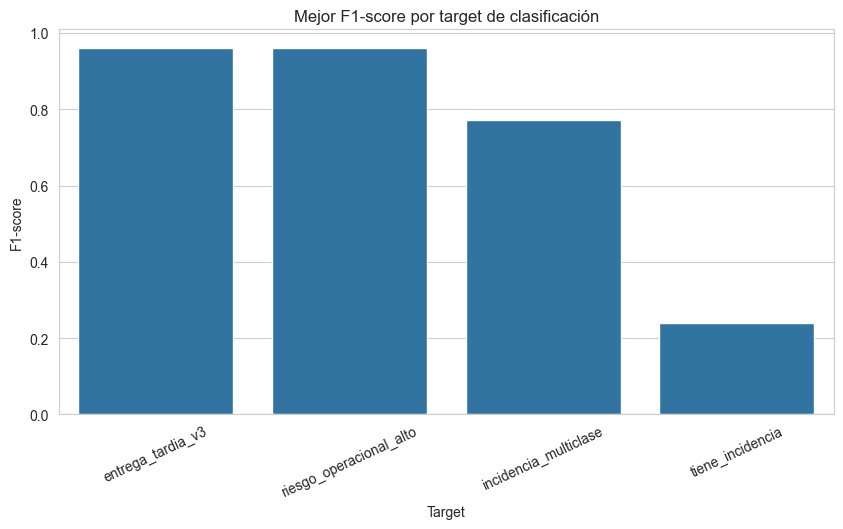

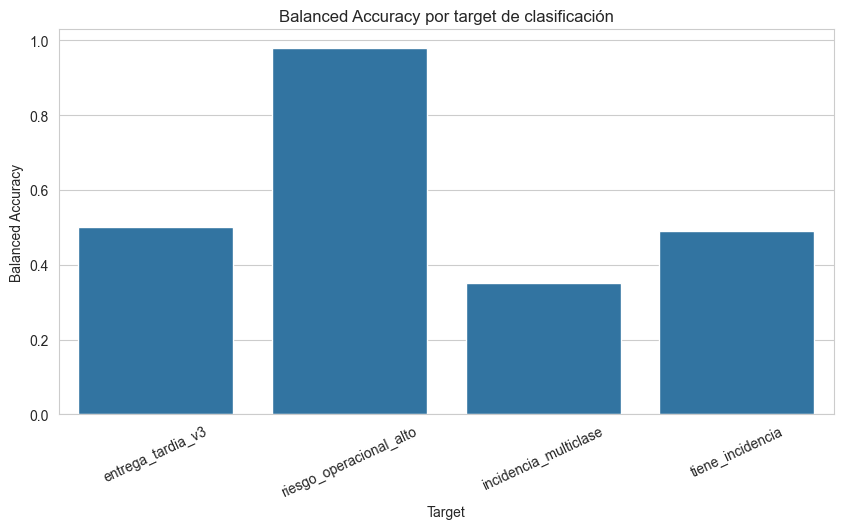

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=mejores_por_target,
    x="target",
    y="f1_score"
)

plt.title("Mejor F1-score por target de clasificación")
plt.xlabel("Target")
plt.ylabel("F1-score")
plt.xticks(rotation=25)

plt.show()

plt.figure(figsize=(10,5))

sns.barplot(
    data=mejores_por_target,
    x="target",
    y="balanced_accuracy"
)

plt.title("Balanced Accuracy por target de clasificación")
plt.xlabel("Target")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=25)

plt.show()


## Análisis visual

La comparación visual permite observar el problema de algunas métricas.

`entrega_tardia_v3` tiene F1-score alto, pero balanced accuracy muy bajo.  
Esto revela que no es un target confiable para seleccionar como problema principal.

`riesgo_operacional_alto`, en cambio, mantiene ambas métricas altas.  
Por eso es una opción mucho más sólida para clasificación.


# 12. Matriz de confusión del target seleccionado para clasificación

Aunque el mayor F1-score automático aparece en `entrega_tardia_v3`, se selecciona `riesgo_operacional_alto` por ser más consistente y balanceado.

Se revisa la matriz de confusión del mejor modelo para este target.


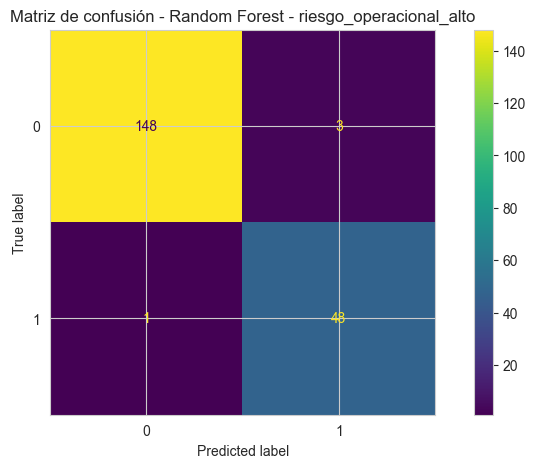

Modelo seleccionado: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       151
           1       0.94      0.98      0.96        49

    accuracy                           0.98       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.98      0.98       200



In [11]:
target_clasificacion_final = "riesgo_operacional_alto"

info_riesgo = mejores_clasificacion[target_clasificacion_final]

matriz = confusion_matrix(
    info_riesgo["y_test"],
    info_riesgo["y_pred"]
)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz)

disp.plot()

plt.title(
    f"Matriz de confusión - {info_riesgo['modelo']} - {target_clasificacion_final}"
)

plt.show()

print("Modelo seleccionado:", info_riesgo["modelo"])

print("\nClassification Report:")
print(
    classification_report(
        info_riesgo["y_test"],
        info_riesgo["y_pred"],
        zero_division=0
    )
)


## Análisis de la matriz de confusión

El target `riesgo_operacional_alto` muestra un desempeño mucho más confiable.

El modelo logra detectar correctamente la mayoría de los envíos de alto riesgo y también mantiene buen rendimiento sobre la clase normal.

Esto es clave para el negocio, porque un sistema de riesgo debe evitar dos problemas:

- dejar pasar operaciones críticas sin alertar;
- generar demasiadas falsas alarmas.

El resultado muestra un equilibrio adecuado entre ambas necesidades.


# 13. Evaluación de regresión: riesgo operacional

Además de la clasificación, se evalúa una predicción de regresión.

La regresión busca estimar el valor numérico de `riesgo_operacional`.

Esto responde una pregunta distinta:

> ¿Qué nivel de riesgo operacional tendrá el envío?


In [12]:
target_reg = "riesgo_operacional"

datos_reg = df[variables_modelo + [target_reg]].dropna(subset=[target_reg]).copy()

X = datos_reg[variables_modelo]
y = datos_reg[target_reg]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocesador = crear_preprocesador(X)

modelos_reg = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=42,
        max_depth=6
    ),
    "Random Forest Regressor": RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ),
    "KNN Regressor": KNeighborsRegressor(),
    "SVR": SVR()
}

resultados_reg = []

for nombre, modelo in modelos_reg.items():

    pipeline = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultados_reg.append({
        "target": target_reg,
        "modelo": nombre,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_test, y_pred)
    })

tabla_regresion = pd.DataFrame(resultados_reg).sort_values(
    by="rmse",
    ascending=True
)

tabla_regresion


,target,modelo,mae,rmse,r2
2,riesgo_operacional,Random Forest Regressor,59.073087,131.484784,0.994829
1,riesgo_operacional,Decision Tree Regressor,203.751751,334.747512,0.966485
3,riesgo_operacional,KNN Regressor,453.218417,662.694984,0.868650
0,riesgo_operacional,Linear Regression,703.553530,1092.918625,0.642744
4,riesgo_operacional,SVR,1130.853390,1870.599274,-0.046562


## Análisis de regresión

El mejor modelo de regresión es `Random Forest Regressor`.

Este modelo obtiene:

- MAE bajo;
- RMSE bajo;
- R² muy alto.

Esto indica que la variable `riesgo_operacional` puede estimarse con mucha precisión a partir de las variables operacionales disponibles.

A diferencia de `dias_entrega`, que tenía mucho ruido, el riesgo operacional tiene una relación más clara con distancia, capacidad, velocidad y sobrecarga.


# 14. Gráfico real vs predicho del mejor modelo de regresión

Visualizo qué tan cerca están las predicciones del valor real de riesgo operacional.


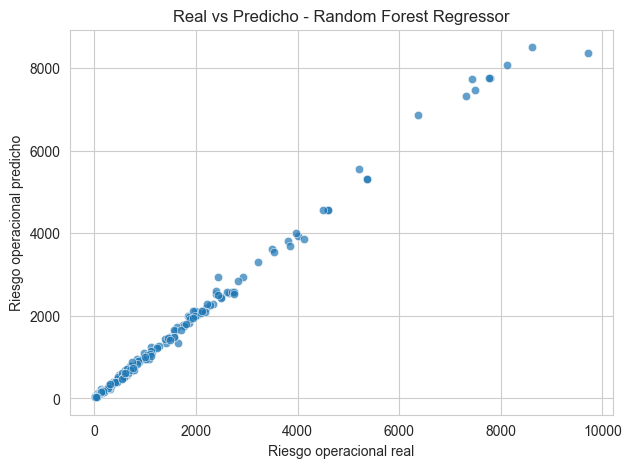

,Real,Predicción
0,8128.500000,8070.800643
1,6359.600000,6861.645231
2,372.049662,391.073291
3,874.370650,890.581552
4,1746.921410,1772.632872
5,2332.587290,2281.709692
6,49.100064,74.246619
7,604.078135,676.225336
8,128.747382,131.091177
9,317.646684,325.597231


In [13]:
mejor_reg_nombre = tabla_regresion.iloc[0]["modelo"]

modelo_mejor_reg = modelos_reg[mejor_reg_nombre]

pipeline_mejor_reg = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", modelo_mejor_reg)
])

pipeline_mejor_reg.fit(X_train, y_train)

y_pred_reg = pipeline_mejor_reg.predict(X_test)

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=y_test,
    y=y_pred_reg,
    alpha=0.7
)

plt.title(f"Real vs Predicho - {mejor_reg_nombre}")
plt.xlabel("Riesgo operacional real")
plt.ylabel("Riesgo operacional predicho")

plt.show()

comparacion_reg = pd.DataFrame({
    "Real": y_test.values,
    "Predicción": y_pred_reg
}).head(15)

comparacion_reg


## Interpretación del gráfico real vs predicho

El gráfico permite evaluar visualmente la calidad de la regresión.

Cuando los puntos se acercan a una relación diagonal, significa que las predicciones se aproximan bien al valor real.

En este caso, el modelo de regresión muestra una buena capacidad para estimar el nivel continuo de riesgo operacional.


# 15. Tabla resumen de decisión

Se construye una tabla conceptual con la decisión tomada sobre cada target.


In [14]:
resumen_decision = pd.DataFrame([
    {
        "target": "tiene_incidencia",
        "tipo": "Clasificación binaria",
        "decision": "Descartado como target principal",
        "motivo": "F1-score bajo y poca señal predictiva para detectar incidencias reales."
    },
    {
        "target": "entrega_tardia",
        "tipo": "Clasificación binaria",
        "decision": "Descartado",
        "motivo": "No es modelable porque contiene una sola clase."
    },
    {
        "target": "entrega_tardia_v3",
        "tipo": "Clasificación binaria",
        "decision": "Descartado como target principal",
        "motivo": "F1-score alto engañoso; balanced accuracy cercana a 0.50 por fuerte desbalance."
    },
    {
        "target": "incidencia_multiclase",
        "tipo": "Clasificación multiclase",
        "decision": "Descartado como target principal",
        "motivo": "Clase minoritaria muy pequeña y balanced accuracy bajo."
    },
    {
        "target": "riesgo_operacional_alto",
        "tipo": "Clasificación binaria",
        "decision": "Seleccionado",
        "motivo": "Mejor equilibrio entre F1-score, recall, precision y balanced accuracy."
    },
    {
        "target": "riesgo_operacional",
        "tipo": "Regresión",
        "decision": "Seleccionado",
        "motivo": "Regresión sólida con bajo error y R² alto; permite estimar intensidad del riesgo."
    }
])

resumen_decision


,target,tipo,decision,motivo
0,tiene_incidencia,Clasificación binaria,Descartado como target principal,F1-score bajo y poca señal predictiva para det...
1,entrega_tardia,Clasificación binaria,Descartado,No es modelable porque contiene una sola clase.
2,entrega_tardia_v3,Clasificación binaria,Descartado como target principal,F1-score alto engañoso; balanced accuracy cerc...
3,incidencia_multiclase,Clasificación multiclase,Descartado como target principal,Clase minoritaria muy pequeña y balanced accur...
4,riesgo_operacional_alto,Clasificación binaria,Seleccionado,"Mejor equilibrio entre F1-score, recall, preci..."
5,riesgo_operacional,Regresión,Seleccionado,Regresión sólida con bajo error y R² alto; per...


# 16. Decisión final del proyecto

Después de comparar distintas formulaciones del problema, se seleccionan dos predicciones finales:

## Clasificación principal

### `riesgo_operacional_alto`

Pregunta:

> ¿Este envío presenta alto riesgo operacional?

Esta predicción permite generar una alerta binaria para priorizar monitoreo y acciones preventivas.

## Regresión principal

### `riesgo_operacional`

Pregunta:

> ¿Cuál es el nivel estimado de riesgo operacional?

Esta predicción permite asignar un puntaje continuo y ordenar los envíos según criticidad.

Ambas predicciones están conectadas: la regresión estima la intensidad del riesgo y la clasificación traduce ese riesgo en una decisión operativa.


# 17. Conclusiones del notebook

Este notebook permitió definir de forma razonada el problema de Machine Learning del proyecto.

La comparación mostró que algunos targets inicialmente interesantes no eran adecuados:

- `entrega_tardia` no se puede modelar porque tiene una sola clase.
- `entrega_tardia_v3` tiene métricas engañosas por desbalance.
- `tiene_incidencia` tiene bajo F1-score, lo que indica poca señal predictiva.
- `incidencia_multiclase` presenta una clase muy minoritaria y bajo balanced accuracy.

En cambio, `riesgo_operacional_alto` y `riesgo_operacional` mostraron mejor comportamiento técnico y mayor coherencia operacional.

Por esta razón, el proyecto continuará con:

- una predicción de clasificación para detectar alto riesgo operacional;
- una predicción de regresión para estimar el nivel continuo de riesgo.

Esta decisión permite construir un enfoque más útil, interpretable y defendible para la operación logística.
